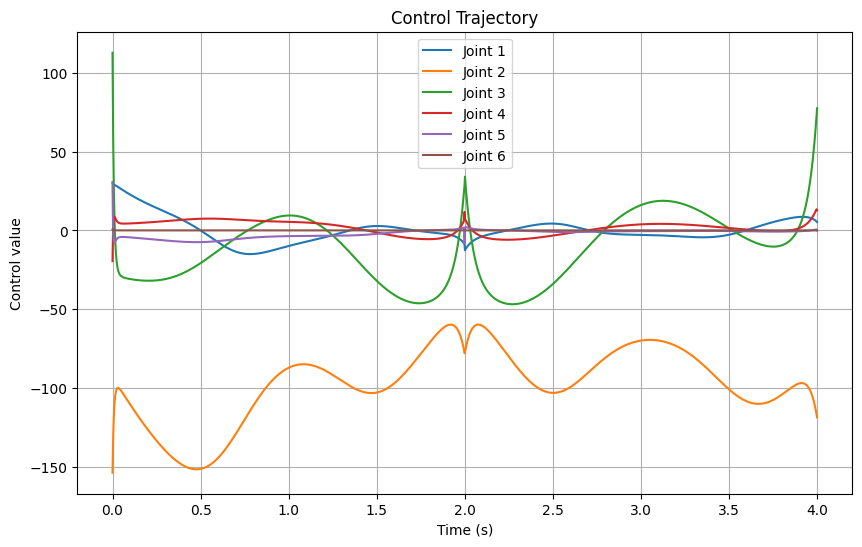

In [10]:
from optimal.RobotController import RobotController
from optimal.Visualizer import Visualizer
import pinocchio as pin
import numpy as np
import mujoco

mjcf_path = "../models/ur10/ur10.xml"
urdf_path = "../models/ur10/ur10.urdf"
robot_mj_model = mujoco.MjModel.from_xml_path(mjcf_path)
robot_pin_model = pin.buildModelFromUrdf(urdf_path)

kp = np.array([400.0, 800.0, 400.0, 100.0, 4.0, 1.0])
kd = np.array([40.0,  80.0,  40.0,  10.0,  .4,  .1])
controller = RobotController(robot_pin_model)

DT = robot_mj_model.opt.timestep
q_start = pin.neutral(robot_pin_model)
q_1 = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])
q_2 = np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])
xs, us = [], []
t_xs, t_us = controller.compute_control(q_start=q_start, q_target=q_1, T=1000, DT=DT, kp=kp, kd=kd, option="boxfddp")
xs.extend(t_xs)
us.extend(t_us)
t_xs, t_us = controller.compute_control(q_start=q_1, q_target=q_2, T=1000, DT=DT, kp=kp, kd=kd, option="boxfddp")
xs.extend(t_xs)
us.extend(t_us)

robot_mj_data = mujoco.MjData(robot_mj_model)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.visualize("position", xs, DT)
# viewer.visualize("control", us, DT)
viewer.plot_controls(us, dt=DT)